In [2]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

In [9]:
df = pd.read_csv("real_estate.csv")
print(df.shape)
df.head()

(150, 8)


,id,city,bhk,price_lakh,area_sqft,dist_center_km,amenity_score,segment
0,1,Bangalore,3,110.8,1300,15.1,7.4,Mid-Range
1,2,Nashik,3,189.9,2077,2.6,8.8,Luxury
2,3,Bangalore,1,35.8,628,20.8,4.6,Budget
3,4,Hyderabad,2,75.3,1170,11.2,6.0,Mid-Range
4,5,Bangalore,3,78.8,1040,14.2,6.1,Mid-Range


In [10]:
# feature selection

features = ['bhk', 'price_lakh', 'area_sqft', 'dist_center_km', 'amenity_score']
X = df[features]

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Elbow method - finding optimal K

inertias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
summary = df.groupby('cluster')[features].mean().round(1)
print(summary)

         bhk  price_lakh  area_sqft  dist_center_km  amenity_score
cluster                                                           
0        3.4       179.9     1982.7             5.2            8.5
1        2.4        86.6     1170.3            14.6            6.7
2        1.3        38.7      581.9            24.7            4.6


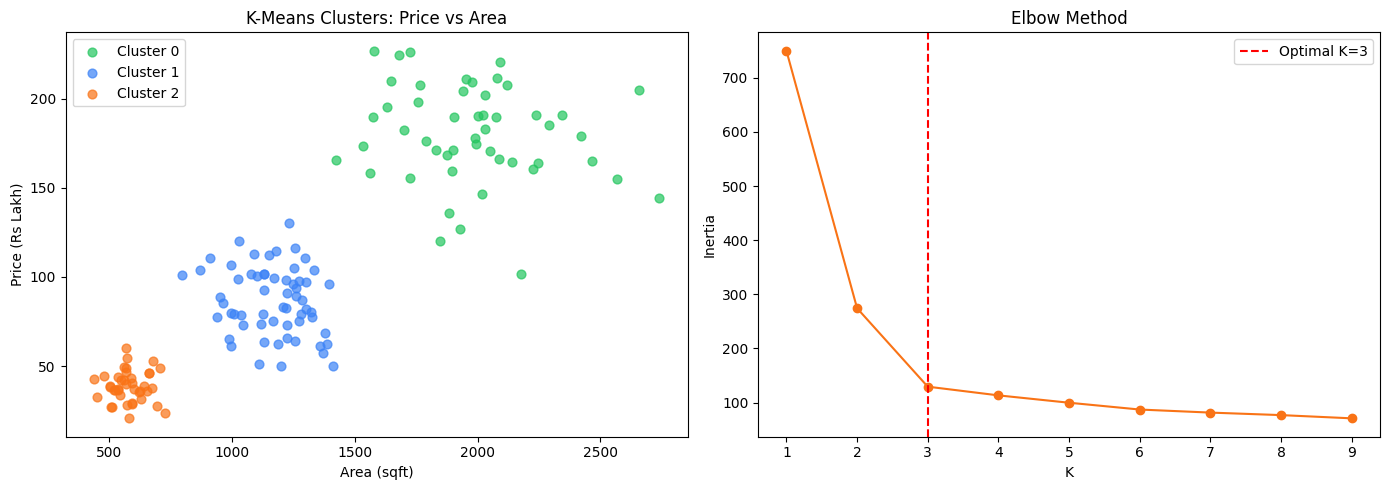

In [19]:
colors = {0: '#22c55e', 1: '#3b82f6', 2: '#f97316'}
labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for c, grp in df.groupby('cluster'):
    ax1.scatter(grp['area_sqft'], grp['price_lakh'],
                c=colors[c], label=labels[c], alpha=0.7, s=40)

ax1.set_xlabel('Area (sqft)'); ax1.set_ylabel('Price (Rs Lakh)')
ax1.set_title('K-Means Clusters: Price vs Area'); ax1.legend()

ax2.plot(range(1, 10), inertias, marker='o', color='#f97316')
ax2.axvline(3, color='red', linestyle='--', label='Optimal K=3')
ax2.set_xlabel('K'); ax2.set_ylabel('Inertia')
ax2.set_title('Elbow Method'); ax2.legend()

plt.tight_layout()
plt.savefig('clusters.png', dpi=150)
plt.show()